<a href="https://colab.research.google.com/github/Tolureis/CMPE-460-Deep-Learning/blob/main/Convolution_For_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 10.5: Convolution for MNIST**

This notebook builds a proper network for 2D convolution.  It works with the MNIST dataset (figure 15.15a), which was the original classic dataset for classifying images.  The network will take a 28x28 grayscale image and classify it into one of 10 classes representing a digit.

The code is adapted from https://nextjournal.com/gkoehler/pytorch-mnist

Work through the cells below, running each cell in turn. In various places you will see the words "TODO". Follow the instructions at these places and make predictions about what is going to happen or write code to complete the functions.

Contact me at udlbookmail@gmail.com if you find any mistakes or have any suggestions.


In [ ]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import random

In [ ]:
# Run this once to load the train and test data straight into a dataloader class
# that will provide the batches

# (It may complain that some files are missing because the files seem to have been
# reorganized on the underlying website, but it still seems to work). If everything is working
# properly, then the whole notebook should run to the end without further problems
# even before you make changes.
batch_size_train = 64
batch_size_test = 1000

# TODO Change this directory to point towards an existing directory
myDir = '/files/'

train_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST(myDir, train=True, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ])),
  batch_size=batch_size_train, shuffle=True)

test_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST(myDir, train=False, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ])),
  batch_size=batch_size_test, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 341kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.14MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.23MB/s]


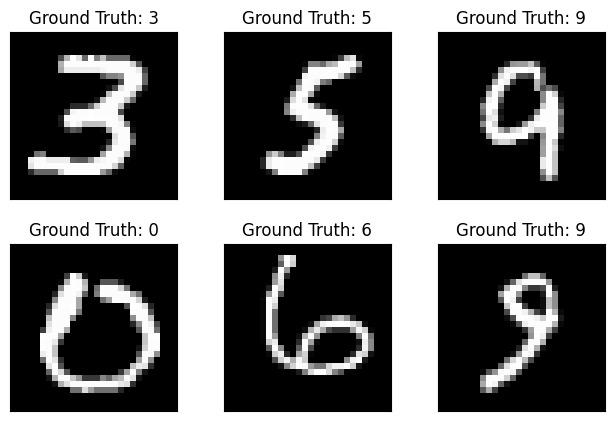

In [ ]:
# Let's draw some of the training data
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)

fig = plt.figure()
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.tight_layout()
  plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Ground Truth: {}".format(example_targets[i]))
  plt.xticks([])
  plt.yticks([])
plt.show()

Define the network.  This is a more typical way to define a network than the sequential structure.  We define a class for the network, and define the parameters in the constructor.  Then we use a function called forward to actually run the network.  It's easy to see how you might use residual connections in this format.

In [ ]:
from os import X_OK
# Replace this class which implements a minimal network (which still does okay)
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        # 1. Valid convolution: 1 input channel → 10 output channels, kernel 5
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)  # output: 10 × 24 × 24

        # 4. Valid convolution: 10 input → 20 output, kernel 5
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5) # output: 20 × 8 × 8 (after pooling1)

        # 5. 2D Dropout
        self.drop = nn.Dropout2d()

        # conv1: 28→24, pool→12
        # conv2: 12→8, pool→4
        # final shape: 20 × 4 × 4 = 320
        self.fc1 = nn.Linear(320, 50)

        # 11. Fully connected: 50 → 10
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        # conv1 → relu → maxpool
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)

        # conv2 → relu → dropout → maxpool
        x = F.relu(self.conv2(x))
        x = self.drop(x)
        x = F.max_pool2d(x, 2)

        # 8. Flatten
        x = x.view(x.size(0), -1)  # flatten(batch, features)

        # FC1 → ReLU
        x = F.relu(self.fc1(x))

        # FC2 → Softmax (log_softmax for NLLLoss)
        x = F.log_softmax(self.fc2(x), dim=1)

        return x

In [ ]:
# He initialization of weights
def weights_init(layer_in):
  if isinstance(layer_in, nn.Linear):
    nn.init.kaiming_uniform_(layer_in.weight)
    layer_in.bias.data.fill_(0.0)

In [ ]:
# Create network
model = Net()
# Initialize model weights
model.apply(weights_init)
# Define optimizer
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.5)

In [ ]:
# Main training routine
def train(epoch):
  model.train()
  # Get each
  for batch_idx, (data, target) in enumerate(train_loader):
    optimizer.zero_grad()
    output = model(data)
    loss = F.nll_loss(output, target)
    loss.backward()
    optimizer.step()
    # Store results
    if batch_idx % 10 == 0:
      print('Train Epoch: {} [{}/{}]\tLoss: {:.6f}'.format(
        epoch, batch_idx * len(data), len(train_loader.dataset), loss.item()))

In [ ]:
# Run on test data
def test():
  model.eval()
  test_loss = 0
  correct = 0
  with torch.no_grad():
    for data, target in test_loader:
      output = model(data)
      test_loss += F.nll_loss(output, target, size_average=False).item()
      pred = output.data.max(1, keepdim=True)[1]
      correct += pred.eq(target.data.view_as(pred)).sum()
  test_loss /= len(test_loader.dataset)
  print('\nTest set: Avg. loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
    test_loss, correct, len(test_loader.dataset),
    100. * correct / len(test_loader.dataset)))

In [ ]:
# Get initial performance
test()
# Train for three epochs
n_epochs = 3
for epoch in range(1, n_epochs + 1):
  train(epoch)
  test()

/usr/local/lib/python3.12/dist-packages/torch/nn/_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))



Test set: Avg. loss: 2.5974, Accuracy: 746/10000 (7%)

Train Epoch: 1 [0/60000]	Loss: 2.640922
Train Epoch: 1 [640/60000]	Loss: 2.306370
Train Epoch: 1 [1280/60000]	Loss: 2.170940
Train Epoch: 1 [1920/60000]	Loss: 2.095190
Train Epoch: 1 [2560/60000]	Loss: 1.995624
Train Epoch: 1 [3200/60000]	Loss: 1.883948
Train Epoch: 1 [3840/60000]	Loss: 1.573951
Train Epoch: 1 [4480/60000]	Loss: 1.265497
Train Epoch: 1 [5120/60000]	Loss: 0.984186
Train Epoch: 1 [5760/60000]	Loss: 0.995709
Train Epoch: 1 [6400/60000]	Loss: 1.115803
Train Epoch: 1 [7040/60000]	Loss: 1.027282
Train Epoch: 1 [7680/60000]	Loss: 0.793693
Train Epoch: 1 [8320/60000]	Loss: 1.028806
Train Epoch: 1 [8960/60000]	Loss: 0.546260
Train Epoch: 1 [9600/60000]	Loss: 0.725633
Train Epoch: 1 [10240/60000]	Loss: 0.498428
Train Epoch: 1 [10880/60000]	Loss: 0.851557
Train Epoch: 1 [11520/60000]	Loss: 0.522455
Train Epoch: 1 [12160/60000]	Loss: 0.875991
Train Epoch: 1 [12800/60000]	Loss: 0.474594
Train Epoch: 1 [13440/60000]	Loss: 0.464

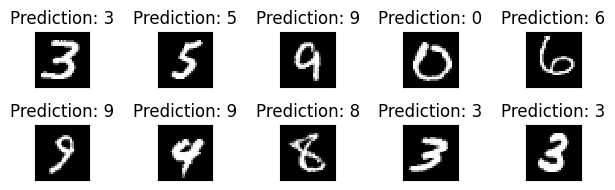

In [ ]:
# Run network on data we got before and show predictions
output = model(example_data)

fig = plt.figure()
for i in range(10):
  plt.subplot(5,5,i+1)
  plt.tight_layout()
  plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Prediction: {}".format(
    output.data.max(1, keepdim=True)[1][i].item()))
  plt.xticks([])
  plt.yticks([])
plt.show()